In [1]:
import pandas
import os
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from sklearn.metrics import silhouette_samples
from sklearn.metrics.cluster import rand_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn import svm
import pandas
import os
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas
import os

In [2]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn import svm
from sklearn.model_selection import KFold
from collections import Counter
from sklearn.datasets import make_classification

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

In [4]:
File = pd.read_excel("/Users/michele/Desktop/DOTTORATO/MOZZARELLE/species rep.xlsx", index_col= 0)

In [5]:
Rep = pd.read_excel("/Users/michele/Desktop/DOTTORATO/MOZZARELLE/replicheb.xlsx", index_col= 0)

In [6]:
Filenuovo = File.reset_index()

X = Filenuovo.drop(["Numero", "Geographic_area"],axis=1)
X1 = X.set_index('SampleID')
y = np.array(Filenuovo["Geographic_area"])
#y=y.astype('int')
target_names = np.array(["Salerno", "Caserta"])
indice = np.array(Filenuovo["SampleID"])
indice = pd.DataFrame(indice)
y2 = pd.DataFrame(y)
y3 = indice.merge(y2, how='inner', left_index=True, right_index=True)
y3.rename(columns={"0_x": "SampleID"}, inplace=True)
y3.rename(columns={"0_y": "Geographic_area"}, inplace=True)
y4 = y3.set_index('SampleID')
y5 = np.array(y4["Geographic_area"])
y6 = y4['Geographic_area']

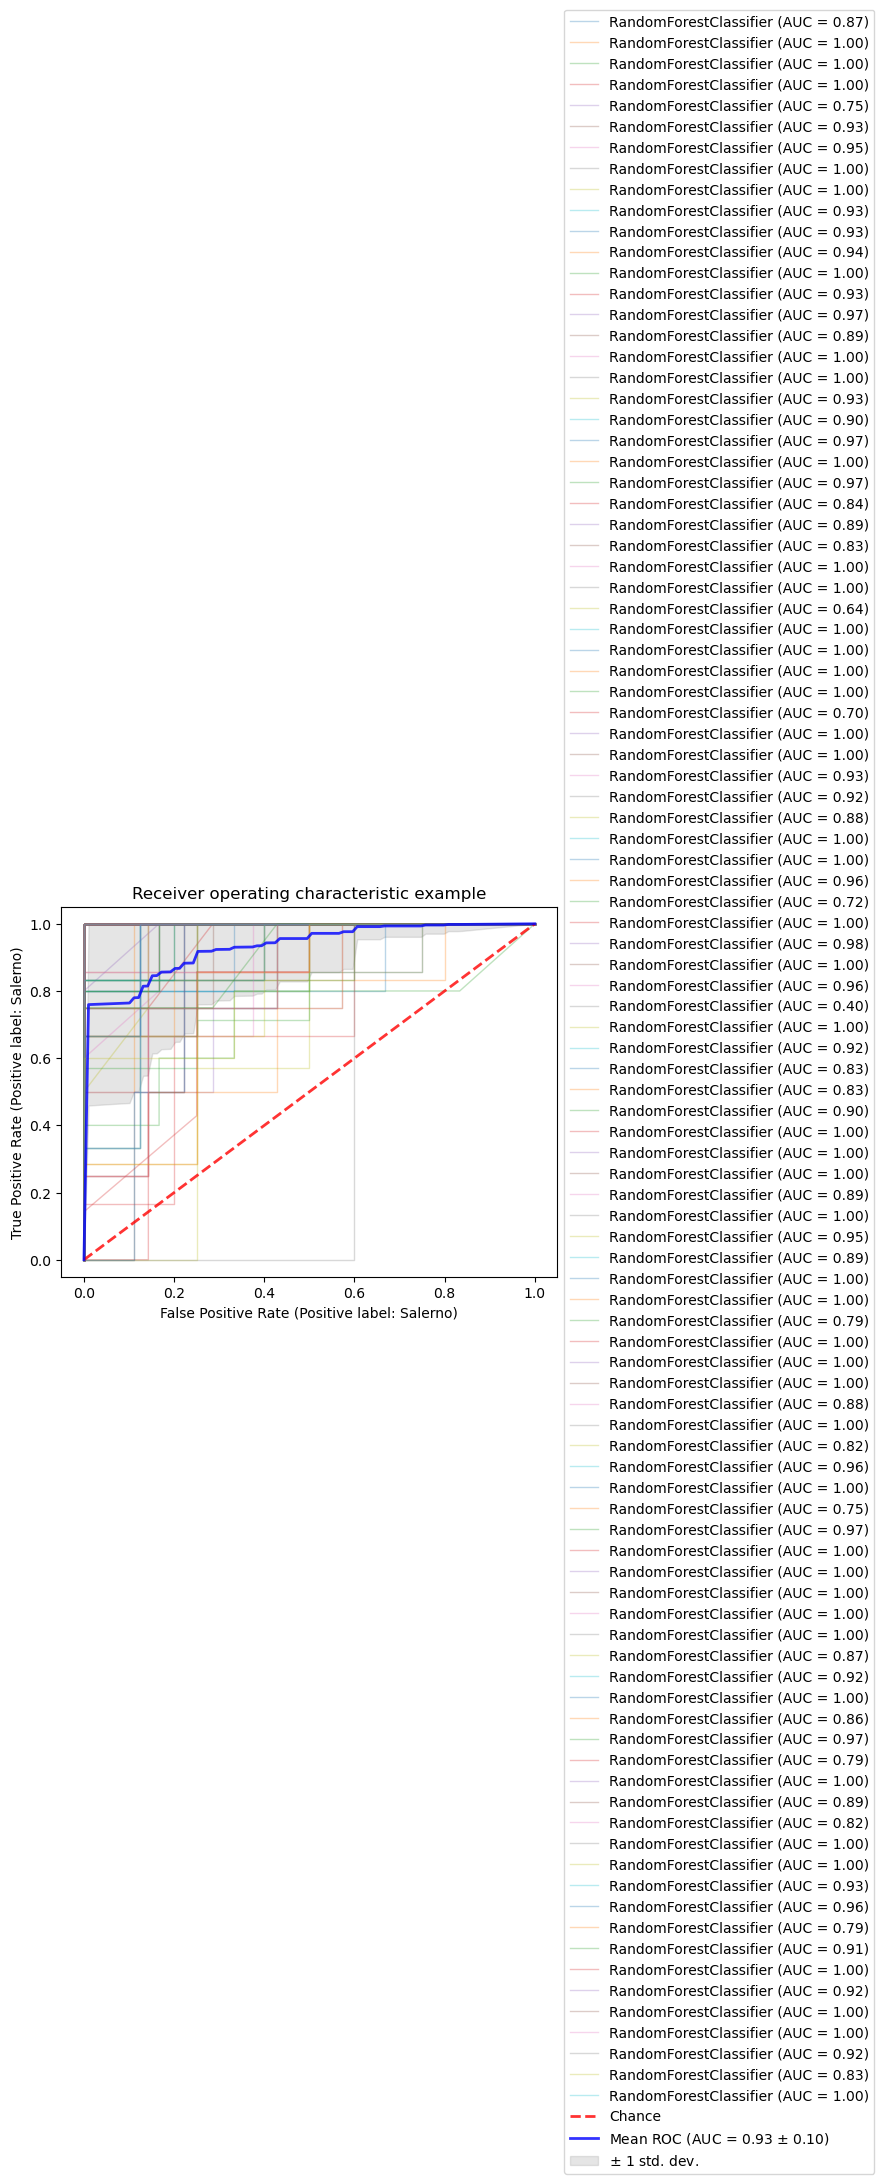

In [11]:
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import RepeatedKFold
# Run classifier with cross-validation and plot ROC curves
cv = RepeatedKFold(n_repeats=20, n_splits=5, random_state=433)
classifier = RandomForestClassifier(n_estimators = 100, verbose = 0, random_state=0)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(X1, y6)):
    classifier.fit(X1.iloc[train], y6.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X1.iloc[test],
        y6.iloc[test],
        #name="ROC fold {}".format(i),
        alpha=0.3,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05],
    title="Receiver operating characteristic example",
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [12]:
import shap


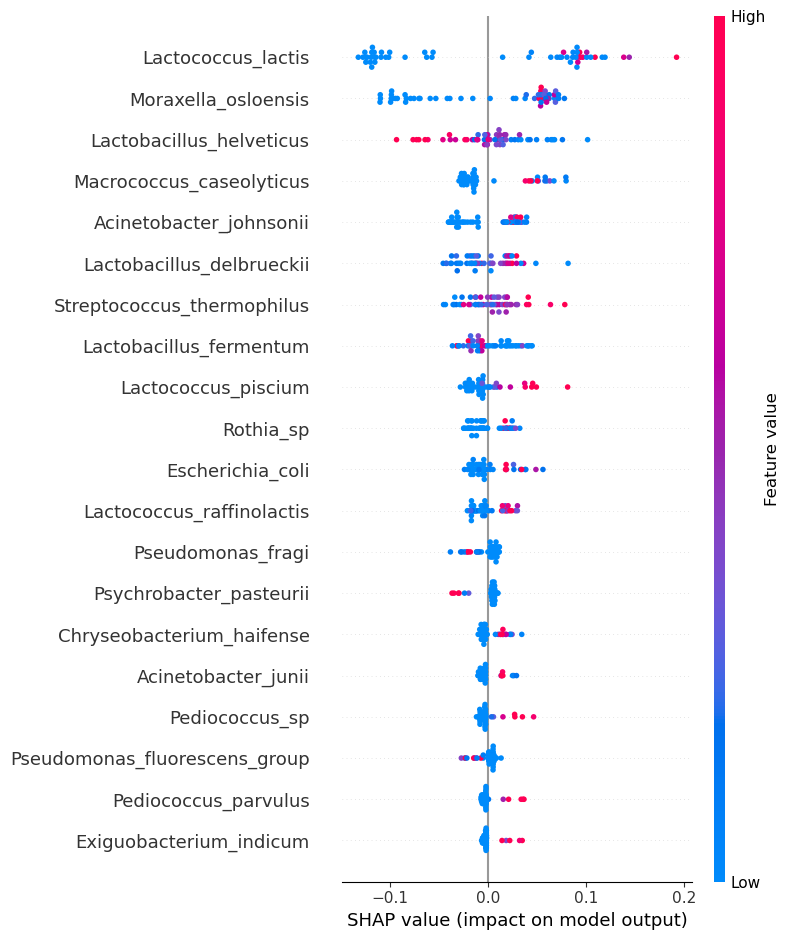

In [30]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X1)[0]
shap.summary_plot(shap_values, X1)

In [29]:
np.shape(shap_values)

(55, 139)

In [8]:
#dataframe vuoto per i 5 test 5x10
dfrepliche = pd.DataFrame(columns = ['Test0', 'Test1', 'Test2', 'Test3', 'Test4'], 
                   index = Rep.index)
 
print("Empty DataFrame With NaN values : \n\n", dfrepliche)

Empty DataFrame With NaN values : 

          Test0 Test1 Test2 Test3 Test4
SampleID                              
A4b        NaN   NaN   NaN   NaN   NaN
B4b        NaN   NaN   NaN   NaN   NaN
C4b        NaN   NaN   NaN   NaN   NaN
D4b        NaN   NaN   NaN   NaN   NaN
E4b        NaN   NaN   NaN   NaN   NaN
F4b        NaN   NaN   NaN   NaN   NaN
N4b        NaN   NaN   NaN   NaN   NaN
O4b        NaN   NaN   NaN   NaN   NaN
Q4b        NaN   NaN   NaN   NaN   NaN
S12        NaN   NaN   NaN   NaN   NaN


In [9]:
#dataframe vuoto per i 5 test 5x10 delle probabilità

dfreplicheprobab = pd.DataFrame(columns = ['Probfold0', 'Probfold1', 'Probfold2', 'Probfold3', 'Probfold4'], 
                   index = Rep.index)
 
print("Empty DataFrame With NaN values : \n\n", dfreplicheprobab)

Empty DataFrame With NaN values : 

          Probfold0 Probfold1 Probfold2 Probfold3 Probfold4
SampleID                                                  
A4b            NaN       NaN       NaN       NaN       NaN
B4b            NaN       NaN       NaN       NaN       NaN
C4b            NaN       NaN       NaN       NaN       NaN
D4b            NaN       NaN       NaN       NaN       NaN
E4b            NaN       NaN       NaN       NaN       NaN
F4b            NaN       NaN       NaN       NaN       NaN
N4b            NaN       NaN       NaN       NaN       NaN
O4b            NaN       NaN       NaN       NaN       NaN
Q4b            NaN       NaN       NaN       NaN       NaN
S12            NaN       NaN       NaN       NaN       NaN


In [10]:
Repnuovo = Rep.reset_index()

RepX = Repnuovo.drop(["Numero", "Geographic_area"],axis=1)
RepX1 = RepX.set_index('SampleID')
Repy = np.array(Repnuovo["Geographic_area"])
Repindice = np.array(Repnuovo["SampleID"])
Repindice = pd.DataFrame(Repindice)
Repy2 = pd.DataFrame(Repy)
Repy3 = Repindice.merge(Repy2, how='inner', left_index=True, right_index=True)
Repy3.rename(columns={"0_x": "SampleID"}, inplace=True)
Repy3.rename(columns={"0_y": "Geographic_area"}, inplace=True)
Repy4 = Repy3.set_index('SampleID')
Repy5 = np.array(Repy4["Geographic_area"])
Repy6 = Repy4['Geographic_area']

In [11]:
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

In [13]:
y_true=list()
y_pred=list()
val_index = list()
y_score = list()
kf = RepeatedKFold(n_repeats=20, n_splits=5, random_state=433)

X1.columns = X1.columns.astype(str)

for i, (train_index, test_index) in enumerate(kf.split(X1)):
    
    X_train = X1.iloc[train_index,:]
    X_val = X1.iloc[test_index,:]
    y_train = y6.iloc[train_index]
    y_val = y6.iloc[test_index]
    val_index.append(X1.index[test_index])
    #val_index.append(test_index) 
    
    modello=RandomForestClassifier(n_estimators = 100, random_state = 0, verbose = 0)
    modello.fit(X_train,y_train)
    
    p=modello.predict(X_val)
    y_true.append(y_val)
    y_pred.append(p)
    prob = modello.predict_proba(X_val)[:, 1]
    y_score.append(prob)
    y_test = modello.predict(RepX1)
    probtest = modello.predict_proba(RepX1)[:, 1]
    dfrepliche['Test'+str(i)] = y_test
    dfreplicheprobab['Probfold'+str(i)] = probtest

In [14]:
dfrepliche

,Test0,Test1,Test2,Test3,Test4,Test5,Test6,Test7,Test8,Test9,...,Test90,Test91,Test92,Test93,Test94,Test95,Test96,Test97,Test98,Test99
SampleID,,,,,,,,,,,,,,,,,,,,,
A4b,Caserta,Salerno,Salerno,Salerno,Salerno,Salerno,Caserta,Salerno,Salerno,Caserta,...,Caserta,Salerno,Caserta,Salerno,Caserta,Salerno,Caserta,Salerno,Caserta,Salerno
B4b,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,...,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno
C4b,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,...,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno
D4b,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,...,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno
E4b,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,...,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno
F4b,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,...,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno
N4b,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,...,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno
O4b,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,...,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno,Salerno
Q4b,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,...,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta,Caserta


In [15]:
dfreplicheprobab

,Probfold0,Probfold1,Probfold2,Probfold3,Probfold4,Probfold5,Probfold6,Probfold7,Probfold8,Probfold9,...,Probfold90,Probfold91,Probfold92,Probfold93,Probfold94,Probfold95,Probfold96,Probfold97,Probfold98,Probfold99
SampleID,,,,,,,,,,,,,,,,,,,,,
A4b,0.28,0.51,0.53,0.53,0.62,0.51,0.45,0.52,0.63,0.18,...,0.41,0.55,0.34,0.52,0.50,0.58,0.49,0.57,0.14,0.51
B4b,0.86,0.89,0.88,0.86,0.83,0.85,0.75,0.91,0.86,0.87,...,0.89,0.77,0.86,0.84,0.78,0.83,0.88,0.88,0.94,0.72
C4b,0.76,0.82,0.77,0.84,0.83,0.77,0.78,0.90,0.68,0.82,...,0.81,0.70,0.84,0.79,0.74,0.85,0.77,0.86,0.79,0.68
D4b,0.74,0.86,0.80,0.81,0.90,0.83,0.85,0.90,0.78,0.56,...,0.71,0.84,0.83,0.86,0.80,0.85,0.84,0.76,0.77,0.83
E4b,0.72,0.72,0.71,0.75,0.78,0.79,0.58,0.76,0.72,0.76,...,0.72,0.69,0.77,0.77,0.52,0.70,0.73,0.90,0.70,0.56
F4b,0.78,0.74,0.77,0.85,0.86,0.83,0.67,0.88,0.76,0.81,...,0.80,0.67,0.89,0.76,0.78,0.77,0.81,0.84,0.80,0.76
N4b,0.66,0.60,0.59,0.75,0.81,0.64,0.61,0.76,0.67,0.63,...,0.59,0.57,0.81,0.71,0.64,0.82,0.73,0.67,0.63,0.56
O4b,0.85,0.80,0.86,0.79,0.95,0.83,0.87,0.76,0.81,0.90,...,0.85,0.77,0.90,0.79,0.89,0.83,0.84,0.94,0.72,0.87
Q4b,0.46,0.14,0.18,0.15,0.26,0.48,0.19,0.23,0.22,0.22,...,0.16,0.18,0.23,0.21,0.48,0.39,0.15,0.39,0.24,0.19


In [16]:
t = np.hstack(y_true)
w = np.hstack(y_pred)
g = np.hstack(y_score)
index = np.hstack(val_index)

In [17]:
from sklearn.datasets import make_classification
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

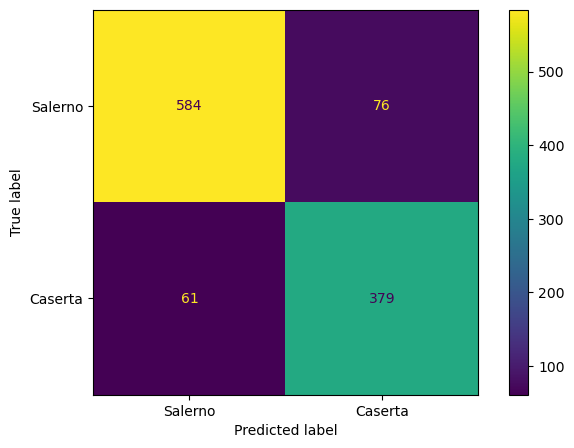

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
cmp = ConfusionMatrixDisplay(
    confusion_matrix(t, w),
    display_labels=["Salerno", "Caserta"],
)

cmp.plot(ax=ax)
plt.show();

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(t, w)

0.8754545454545455

In [20]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score